# Week 4 – Data Visualization and Interpretation for Healthcare Insights

**YUVAIntern Healthcare Data Science Internship 2026**

This notebook presents the Week 4 data visualization and interpretation workflow using the synthetic chemical-compound dataset developed during the internship.

The analysis focuses on visualizing molecular descriptors, comparing Active and Inactive compounds, identifying relationships between variables, and interpreting patterns relevant to computational healthcare and pharmaceutical research.

## 1. Objective

The objective of Week 4 is to communicate insights from the synthetic chemical-compound dataset using appropriate data visualizations.

The analysis focuses on:

- Molecular descriptor distributions
- Active versus Inactive compound comparisons
- Relationships between molecular descriptors
- Correlation analysis
- Pairwise relationships between variables
- Interpretation of observed patterns
- Data-driven conclusions and recommendations

The visualizations are generated using Python libraries including Matplotlib and Seaborn.

## 2. Introduction

Data visualization is an important component of healthcare research, pharmaceutical research, and computational drug discovery because it enables complex datasets to be explored and interpreted effectively.

Molecular descriptors provide quantitative representations of important chemical and physicochemical characteristics of molecules. In this project, Molecular Weight, LogP, HBA, HBD, TPSA, and Rotatable Bonds are analysed to understand molecular-property distributions and relationships.

Exploratory visualization can help identify patterns, relationships, differences between compound groups, and potential outliers before applying computational approaches such as QSAR and machine learning.

Since the dataset used in this project is synthetic and the bioactivity labels are not experimentally validated, the observations should be considered exploratory rather than confirmed biological relationships.

## 3. Project Overview

The project explores whether visualization of molecular descriptors can reveal differences between Active and Inactive chemical compounds and identify relationships within the chemical-property space.

The overall workflow is:

**Dataset → Data Inspection → Data Preprocessing → Molecular Descriptor Analysis → Exploratory Visualization → Active/Inactive Comparison → Correlation Analysis → Chemical-Space Analysis → Outlier Analysis → Interpretation**

The analysis provides a foundation for subsequent computational approaches such as QSAR, machine learning, molecular fingerprint analysis, and AI-assisted drug discovery.

In [3]:
# ============================================================
# S.NO. 4 — IMPORT LIBRARIES
# ============================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

print("Libraries imported successfully.")

Libraries imported successfully.


## 5. Dataset Loading

The existing synthetic chemical-compound dataset generated during the internship is loaded for Week 4 visualization and interpretation.

The dataset contains 500 chemical compounds represented using six molecular descriptors and a binary bioactivity classification.

In [7]:
# ============================================================
# S.NO. 5 — LOAD DATASET
# ============================================================

import pandas as pd
from google.colab import files

uploaded = files.upload()

file_name = next(iter(uploaded))

df = pd.read_csv(file_name)

print("Dataset loaded successfully.")
print("Dataset shape:", df.shape)

display(df.head())

Saving synthetic_compounds.csv to synthetic_compounds (1).csv
Dataset loaded successfully.
Dataset shape: (500, 8)


,Compound_ID,Molecular_Weight,LogP,HBA,HBD,TPSA,Rotatable_Bonds,Bioactivity
0,CMP1,374.835708,3.926178,7,0,71.342071,8,Active
1,CMP2,343.086785,4.909417,1,4,102.497528,8,Active
2,CMP3,382.384427,1.601432,8,3,62.080716,7,Inactive
3,CMP4,426.151493,3.562969,3,3,59.016160,4,Inactive
4,CMP5,338.292331,2.349357,6,4,65.345130,2,Active


## 6. Dataset Description

The dataset consists of 500 synthetic chemical compounds.

Each compound is represented using the following molecular descriptors:

| Descriptor | Abbreviation | Description |
|---|---|---|
| Molecular Weight | MW | Represents molecular mass |
| LogP | LogP | Indicates lipophilic character |
| Hydrogen Bond Acceptors | HBA | Number of hydrogen-bond accepting atoms |
| Hydrogen Bond Donors | HBD | Number of hydrogen-bond donating atoms |
| Topological Polar Surface Area | TPSA | Represents molecular polar surface characteristics |
| Rotatable Bonds | RB | Indicates molecular flexibility |

The target variable, `Bioactivity`, consists of two classes:

- Active
- Inactive

## 7. Dataset Inspection

The dataset is inspected to verify its dimensions, column names, data types, sample records, and overall structure before visualization.

In [8]:
# ============================================================
# S.NO. 7 — DATASET INSPECTION
# ============================================================

print("Dataset Shape:")
print(df.shape)

print("\nColumn Names:")
print(df.columns.tolist())

print("\nData Types:")
print(df.dtypes)

print("\nFirst Five Records:")
display(df.head())

Dataset Shape:
(500, 8)

Column Names:
['Compound_ID', 'Molecular_Weight', 'LogP', 'HBA', 'HBD', 'TPSA', 'Rotatable_Bonds', 'Bioactivity']

Data Types:
Compound_ID          object
Molecular_Weight    float64
LogP                float64
HBA                   int64
HBD                   int64
TPSA                float64
Rotatable_Bonds       int64
Bioactivity          object
dtype: object

First Five Records:


,Compound_ID,Molecular_Weight,LogP,HBA,HBD,TPSA,Rotatable_Bonds,Bioactivity
0,CMP1,374.835708,3.926178,7,0,71.342071,8,Active
1,CMP2,343.086785,4.909417,1,4,102.497528,8,Active
2,CMP3,382.384427,1.601432,8,3,62.080716,7,Inactive
3,CMP4,426.151493,3.562969,3,3,59.016160,4,Inactive
4,CMP5,338.292331,2.349357,6,4,65.345130,2,Active


## 8. Data Preprocessing

Before performing visualization, the dataset is checked for missing values, duplicate records, data types, and consistency of the selected molecular descriptors.

The molecular descriptors are treated as numerical variables, while `Bioactivity` is treated as a categorical variable containing Active and Inactive classes.

No experimentally validated values are introduced or artificially modified during preprocessing.

In [9]:
# ============================================================
# S.NO. 8 — DATA PREPROCESSING AND DATA QUALITY CHECK
# ============================================================

# Check missing values
print("Missing Values:")
display(df.isnull().sum())

# Check duplicate records
print("\nNumber of Duplicate Records:")
print(df.duplicated().sum())

# Check data types
print("\nData Types:")
display(df.dtypes)

# Check bioactivity classes
print("\nBioactivity Class Counts:")
display(df["Bioactivity"].value_counts())

# Check selected molecular descriptors
descriptors = [
    "Molecular_Weight",
    "LogP",
    "HBA",
    "HBD",
    "TPSA",
    "Rotatable_Bonds"
]

print("\nSelected Molecular Descriptors:")
print(descriptors)

# Check whether descriptor columns contain missing values
print("\nMissing Values in Molecular Descriptors:")
display(df[descriptors].isnull().sum())

# Basic numerical summary
print("\nNumerical Summary:")
display(df[descriptors].describe().round(3))

Missing Values:


,0
Compound_ID,0
Molecular_Weight,0
LogP,0
HBA,0
HBD,0
TPSA,0
Rotatable_Bonds,0
Bioactivity,0



Number of Duplicate Records:
0

Data Types:


,0
Compound_ID,object
Molecular_Weight,float64
LogP,float64
HBA,int64
HBD,int64
TPSA,float64
Rotatable_Bonds,int64
Bioactivity,object



Bioactivity Class Counts:


,count
Bioactivity,
Active,263
Inactive,237



Selected Molecular Descriptors:
['Molecular_Weight', 'LogP', 'HBA', 'HBD', 'TPSA', 'Rotatable_Bonds']

Missing Values in Molecular Descriptors:


,0
Molecular_Weight,0
LogP,0
HBA,0
HBD,0
TPSA,0
Rotatable_Bonds,0



Numerical Summary:


,Molecular_Weight,LogP,HBA,HBD,TPSA,Rotatable_Bonds
count,500.000,500.000,500.000,500.000,500.000,500.000
mean,350.342,3.032,4.964,2.568,75.614,6.078
std,49.063,0.978,2.558,1.716,19.400,3.177
min,187.937,0.303,1.000,0.000,14.610,1.000
25%,314.985,2.405,3.000,1.000,63.026,3.000
50%,350.640,3.029,5.000,3.000,75.007,6.000
75%,381.839,3.651,7.000,4.000,88.478,9.000
max,542.637,5.632,9.000,5.000,138.862,11.000


## 9. Molecular Descriptor Selection

Six molecular descriptors are selected for visualization and analysis:

- Molecular Weight
- LogP
- HBA
- HBD
- TPSA
- Rotatable Bonds

These descriptors represent different aspects of molecular size, lipophilicity, polarity, hydrogen-bonding characteristics, and molecular flexibility.

In [10]:
# ============================================================
# S.NO. 9 — SELECT MOLECULAR DESCRIPTORS
# ============================================================

descriptors = [
    "Molecular_Weight",
    "LogP",
    "HBA",
    "HBD",
    "TPSA",
    "Rotatable_Bonds"
]

print("Selected Molecular Descriptors:")
print(descriptors)

Selected Molecular Descriptors:
['Molecular_Weight', 'LogP', 'HBA', 'HBD', 'TPSA', 'Rotatable_Bonds']


## 10. Descriptive Statistical Analysis

Descriptive statistics are calculated for the selected molecular descriptors to summarize their central tendency, dispersion, and overall distribution.

In [11]:
# ============================================================
# S.NO. 10 — DESCRIPTIVE STATISTICS
# ============================================================

descriptive_statistics = df[descriptors].describe()

display(descriptive_statistics.round(3))

,Molecular_Weight,LogP,HBA,HBD,TPSA,Rotatable_Bonds
count,500.000,500.000,500.000,500.000,500.000,500.000
mean,350.342,3.032,4.964,2.568,75.614,6.078
std,49.063,0.978,2.558,1.716,19.400,3.177
min,187.937,0.303,1.000,0.000,14.610,1.000
25%,314.985,2.405,3.000,1.000,63.026,3.000
50%,350.640,3.029,5.000,3.000,75.007,6.000
75%,381.839,3.651,7.000,4.000,88.478,9.000
max,542.637,5.632,9.000,5.000,138.862,11.000


## 11. Distribution of Molecular Descriptors

Histograms are used to visualize the distributions of the six molecular descriptors.

These plots provide an overview of the physicochemical characteristics and chemical-property space represented in the dataset.

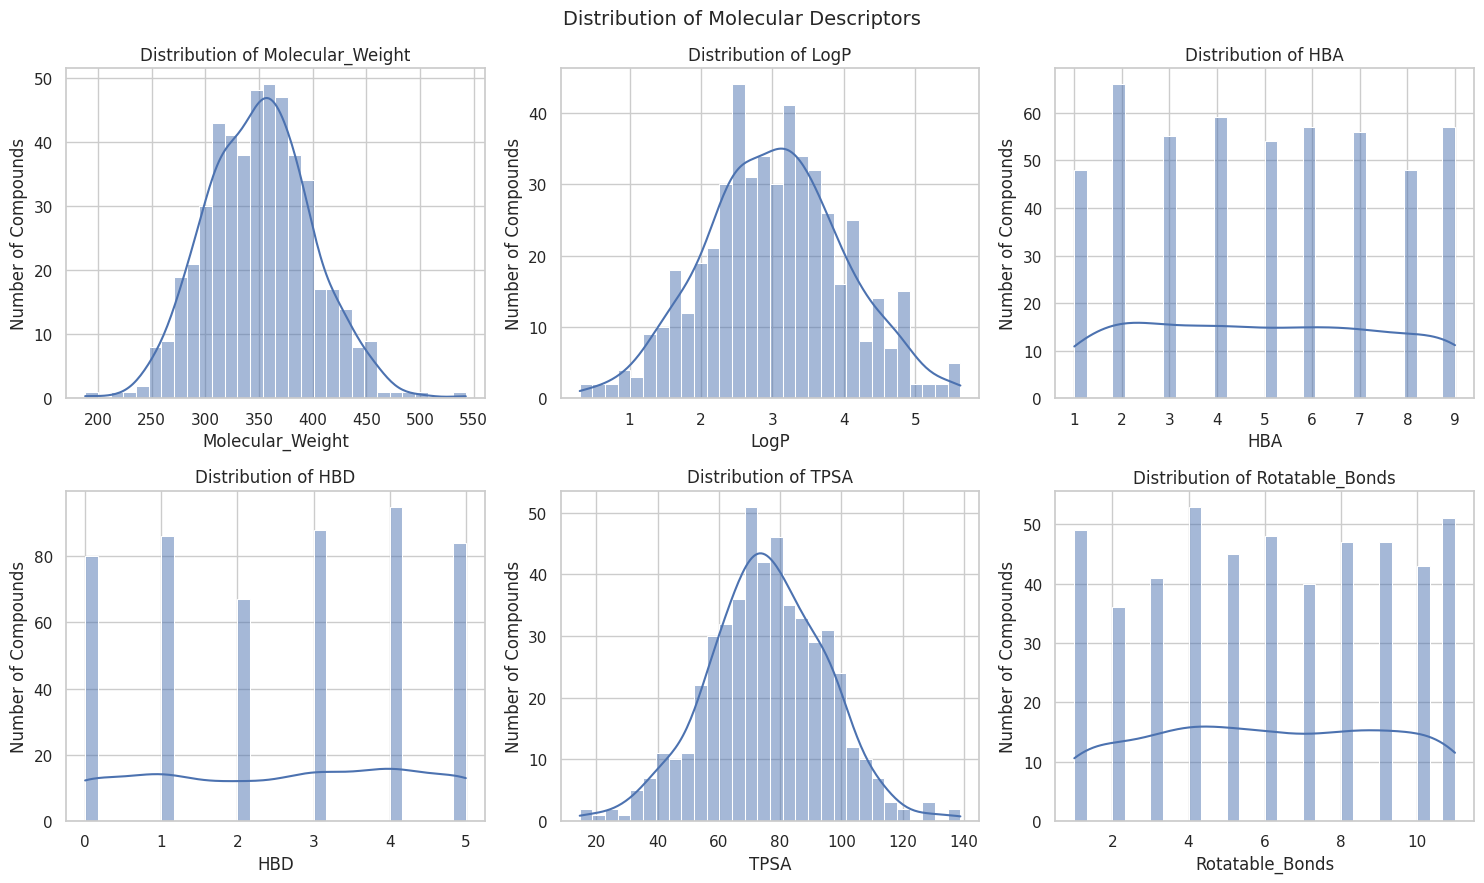

In [12]:
# ============================================================
# S.NO. 11 — DISTRIBUTION OF MOLECULAR DESCRIPTORS
# ============================================================

fig, axes = plt.subplots(2, 3, figsize=(15, 9))

for ax, descriptor in zip(axes.flatten(), descriptors):

    sns.histplot(
        data=df,
        x=descriptor,
        bins=30,
        kde=True,
        ax=ax
    )

    ax.set_title(f"Distribution of {descriptor}")
    ax.set_xlabel(descriptor)
    ax.set_ylabel("Number of Compounds")

plt.suptitle(
    "Distribution of Molecular Descriptors",
    fontsize=14
)

plt.tight_layout()
plt.show()

## 12. Bioactivity Class Distribution

A count plot is used to compare the number of Active and Inactive compounds in the dataset.

This visualization helps examine the distribution of the two bioactivity classes.

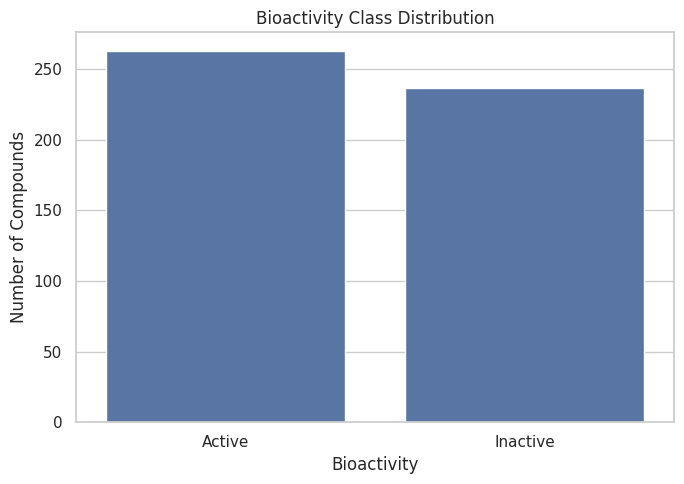

Bioactivity Class Counts:
Bioactivity
Active      263
Inactive    237
Name: count, dtype: int64


In [13]:
# ============================================================
# S.NO. 12 — BIOACTIVITY CLASS DISTRIBUTION
# ============================================================

plt.figure(figsize=(7, 5))

sns.countplot(
    data=df,
    x="Bioactivity"
)

plt.title("Bioactivity Class Distribution")
plt.xlabel("Bioactivity")
plt.ylabel("Number of Compounds")

plt.tight_layout()
plt.show()

print("Bioactivity Class Counts:")
print(df["Bioactivity"].value_counts())

## 13. Comparative Analysis of Active and Inactive Compounds

Box plots are used to compare Molecular Weight, LogP, HBA, HBD, TPSA, and Rotatable Bonds between Active and Inactive compounds.

The comparison allows differences in the median, spread, and potential outliers of each molecular property to be visually examined.

Because the dataset is synthetic, observed differences are treated as exploratory patterns rather than experimentally validated structure–activity relationships.

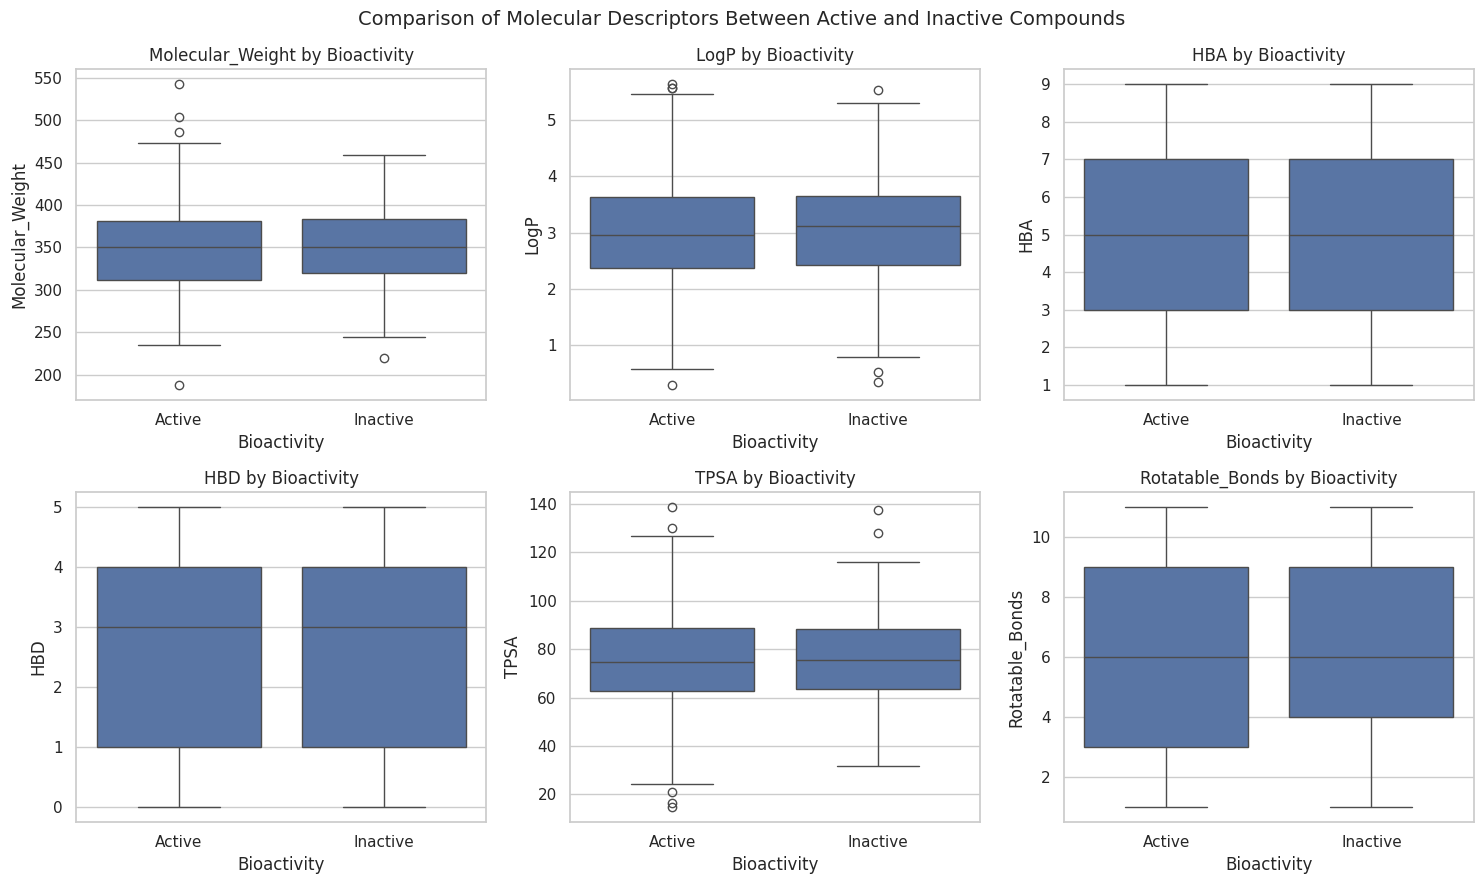

In [14]:
# ============================================================
# S.NO. 13 — ACTIVE VS INACTIVE COMPARISON
# ============================================================

fig, axes = plt.subplots(2, 3, figsize=(15, 9))

for ax, descriptor in zip(axes.flatten(), descriptors):

    sns.boxplot(
        data=df,
        x="Bioactivity",
        y=descriptor,
        ax=ax
    )

    ax.set_title(f"{descriptor} by Bioactivity")
    ax.set_xlabel("Bioactivity")
    ax.set_ylabel(descriptor)

plt.suptitle(
    "Comparison of Molecular Descriptors Between Active and Inactive Compounds",
    fontsize=14
)

plt.tight_layout()
plt.show()

## 14. Interpretation of Active versus Inactive Comparison

The comparative analysis provides an initial understanding of the physicochemical characteristics associated with the two bioactivity classes.

The distributions of the molecular descriptors should be examined collectively rather than independently. Substantial overlap between Active and Inactive compounds indicates that individual molecular descriptors may not clearly distinguish the two classes.

Bioactivity is influenced by multiple structural, physicochemical, and biological factors, and the six selected descriptors provide only a limited representation of molecular structure.

Therefore, the observed patterns are considered useful for exploratory medicinal chemistry analysis and feature understanding rather than experimentally validated structure–activity relationships.

## 15. Correlation Heatmap

A correlation heatmap is generated to examine the strength and direction of relationships among the six molecular descriptors.

Correlation coefficients range from -1 to +1:

- Positive values indicate that two descriptors tend to increase together.
- Negative values indicate an inverse relationship.
- Values close to zero indicate a relatively weak linear relationship.

The heatmap provides a compact representation of relationships within the molecular-property space.

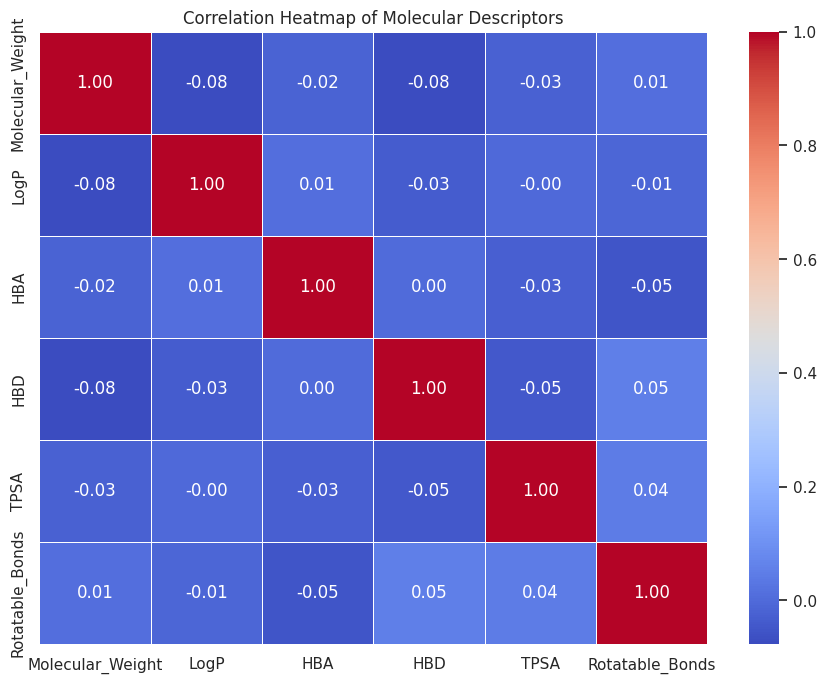

Correlation Matrix:


,Molecular_Weight,LogP,HBA,HBD,TPSA,Rotatable_Bonds
Molecular_Weight,1.00,-0.08,-0.02,-0.08,-0.03,0.01
LogP,-0.08,1.00,0.01,-0.03,-0.00,-0.01
HBA,-0.02,0.01,1.00,0.00,-0.03,-0.05
HBD,-0.08,-0.03,0.00,1.00,-0.05,0.05
TPSA,-0.03,-0.00,-0.03,-0.05,1.00,0.04
Rotatable_Bonds,0.01,-0.01,-0.05,0.05,0.04,1.00


In [15]:
# ============================================================
# S.NO. 15 — CORRELATION HEATMAP
# ============================================================

correlation_matrix = df[descriptors].corr()

plt.figure(figsize=(9, 7))

sns.heatmap(
    correlation_matrix,
    annot=True,
    cmap="coolwarm",
    fmt=".2f",
    linewidths=0.5
)

plt.title("Correlation Heatmap of Molecular Descriptors")

plt.tight_layout()
plt.show()

print("Correlation Matrix:")
display(correlation_matrix.round(2))

## 16. Pairwise Descriptor Analysis

Pairwise analysis is used to examine relationships between multiple molecular descriptors simultaneously.

Scatter plots allow relationships between pairs of descriptors to be visually assessed, while diagonal distributions provide information about individual variables.

The pairwise analysis complements the correlation heatmap by providing a broader visual representation of the chemical-property space.

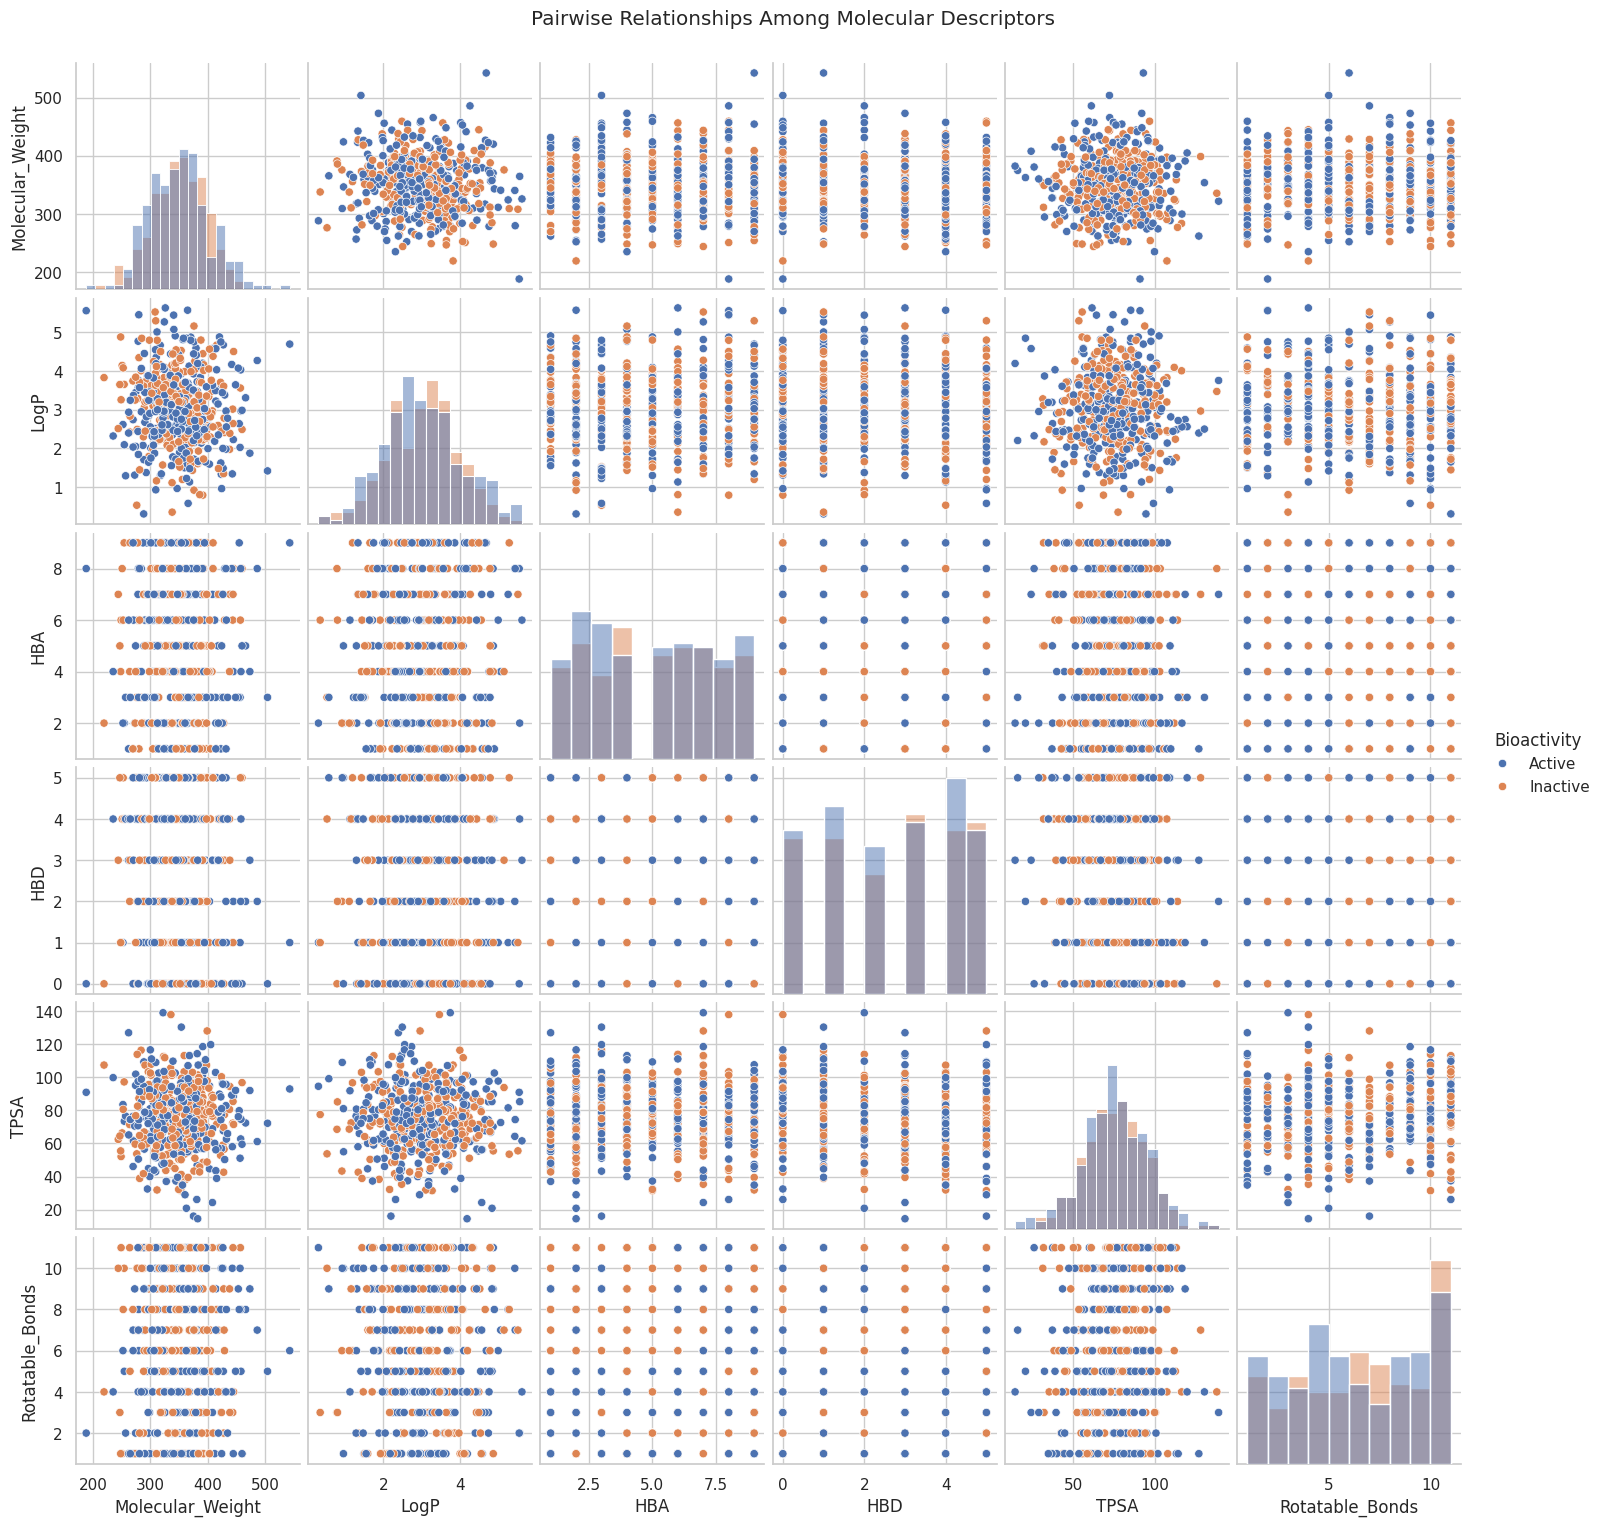

In [16]:
# ============================================================
# S.NO. 16 — PAIRWISE DESCRIPTOR ANALYSIS
# ============================================================

pairplot = sns.pairplot(
    df,
    vars=descriptors,
    hue="Bioactivity",
    diag_kind="hist"
)

pairplot.fig.suptitle(
    "Pairwise Relationships Among Molecular Descriptors",
    y=1.02
)

plt.show()

## 17. Molecular Weight versus LogP

A scatter plot is used to examine the relationship between Molecular Weight and LogP while distinguishing compounds according to their bioactivity classification.

This visualization provides an additional view of the chemical-property space and allows potential patterns or unusual observations to be examined.

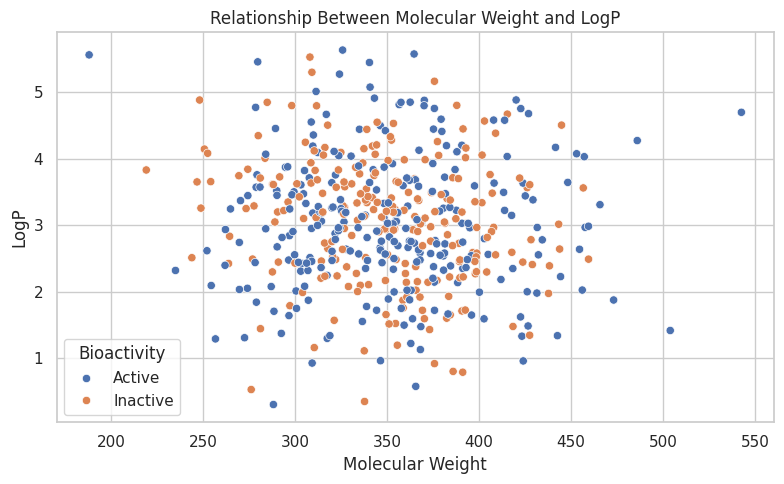

In [17]:
# ============================================================
# S.NO. 17 — MOLECULAR WEIGHT VS LOGP
# ============================================================

plt.figure(figsize=(8, 5))

sns.scatterplot(
    data=df,
    x="Molecular_Weight",
    y="LogP",
    hue="Bioactivity"
)

plt.title("Relationship Between Molecular Weight and LogP")
plt.xlabel("Molecular Weight")
plt.ylabel("LogP")
plt.legend(title="Bioactivity")

plt.tight_layout()
plt.show()

## 18. Outlier Analysis

Potential outliers are examined using box plots for Molecular Weight, LogP, HBA, HBD, TPSA, and Rotatable Bonds.

An observation appearing as an outlier does not necessarily represent an error. In chemical datasets, unusual molecular properties may correspond to compounds with genuinely different structural or physicochemical characteristics.

Therefore, potential outliers are examined rather than automatically removed.

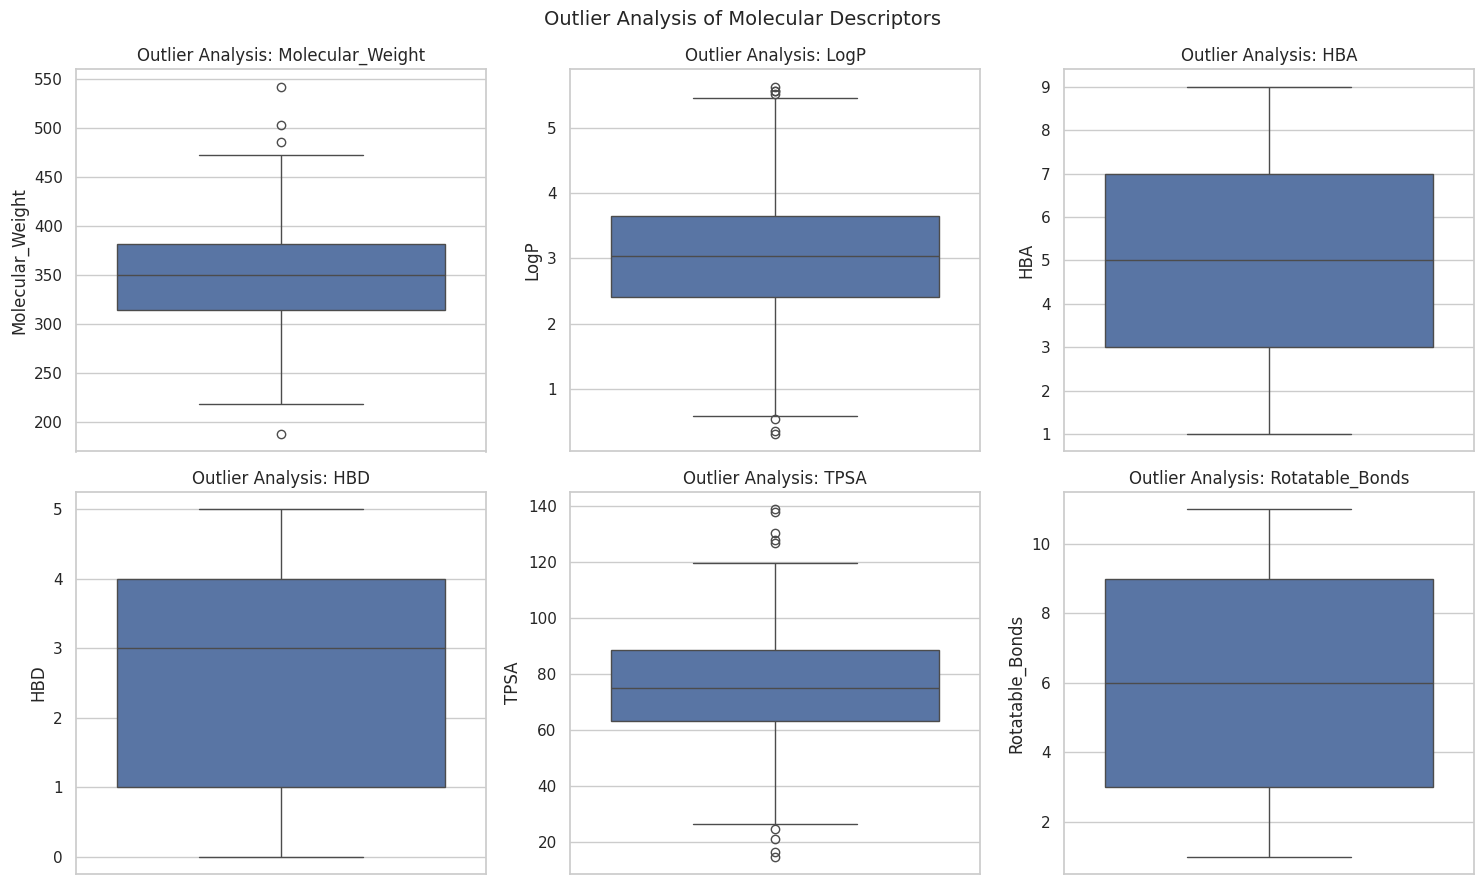

In [18]:
# ============================================================
# S.NO. 18 — OUTLIER VISUALIZATION
# ============================================================

fig, axes = plt.subplots(2, 3, figsize=(15, 9))

for ax, descriptor in zip(axes.flatten(), descriptors):

    sns.boxplot(
        data=df,
        y=descriptor,
        ax=ax
    )

    ax.set_title(f"Outlier Analysis: {descriptor}")
    ax.set_ylabel(descriptor)

plt.suptitle(
    "Outlier Analysis of Molecular Descriptors",
    fontsize=14
)

plt.tight_layout()
plt.show()

## 19. IQR-Based Outlier Identification

The Interquartile Range (IQR) method is used to identify potential numerical outliers.

For each molecular descriptor:

**IQR = Q3 − Q1**

Potential outliers are observations below:

**Q1 − 1.5 × IQR**

or above:

**Q3 + 1.5 × IQR**

The identified observations are retained because unusual molecular properties do not necessarily represent data errors.

In [19]:
# ============================================================
# S.NO. 19 — IQR-BASED OUTLIER IDENTIFICATION
# ============================================================

outlier_summary = []

for descriptor in descriptors:

    Q1 = df[descriptor].quantile(0.25)
    Q3 = df[descriptor].quantile(0.75)

    IQR = Q3 - Q1

    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    outliers = df[
        (df[descriptor] < lower_bound) |
        (df[descriptor] > upper_bound)
    ]

    outlier_summary.append({
        "Molecular Descriptor": descriptor,
        "Q1": Q1,
        "Q3": Q3,
        "IQR": IQR,
        "Lower Bound": lower_bound,
        "Upper Bound": upper_bound,
        "Potential Outliers": len(outliers)
    })

outlier_table = pd.DataFrame(outlier_summary)

display(outlier_table.round(3))

,Molecular Descriptor,Q1,Q3,IQR,Lower Bound,Upper Bound,Potential Outliers
0,Molecular_Weight,314.985,381.839,66.855,214.703,482.121,4
1,LogP,2.405,3.651,1.247,0.535,5.521,7
2,HBA,3.000,7.000,4.000,-3.000,13.000,0
3,HBD,1.000,4.000,3.000,-3.500,8.500,0
4,TPSA,63.026,88.478,25.452,24.848,126.656,9
5,Rotatable_Bonds,3.000,9.000,6.000,-6.000,18.000,0


## 20. Final Interpretation, Recommendations and Conclusion

### Interpretation

The visualization workflow provides an exploratory overview of the chemical-property space represented by the synthetic bioactivity dataset.

The molecular descriptor distributions provide information about the physicochemical characteristics of the compounds. The Active versus Inactive comparisons allow the distributions of Molecular Weight, LogP, HBA, HBD, TPSA, and Rotatable Bonds to be examined across the two bioactivity classes.

Correlation and pairwise analyses provide information about relationships among the molecular descriptors, while outlier analysis identifies observations with unusual descriptor values.

The comparative analysis shows substantial overlap across several molecular descriptors between Active and Inactive compounds. Therefore, individual descriptors should not be considered sufficient to explain bioactivity.

From a medicinal chemistry perspective, molecular size, lipophilicity, polarity, hydrogen-bonding characteristics, and molecular flexibility should be considered collectively.

### Key Findings

- The dataset contains 500 synthetic chemical compounds.
- Six molecular descriptors were analysed: Molecular Weight, LogP, HBA, HBD, TPSA, and Rotatable Bonds.
- Molecular-property distributions provide an overview of the chemical-property space.
- Active and Inactive compounds show substantial overlap across several molecular descriptors.
- Correlation and pairwise analyses provide a broader view of relationships among molecular descriptors.
- Outlier analysis identifies unusual descriptor values without automatically treating them as errors.
- Multiple molecular properties should be considered collectively rather than relying on a single descriptor.
- The workflow provides a foundation for QSAR, molecular fingerprint analysis, machine learning, and AI-assisted drug discovery.

### Recommendations

1. Future studies should use experimentally validated molecular structures and bioactivity values.
2. Additional molecular descriptors and molecular fingerprints should be included to provide a more comprehensive representation of chemical structure.
3. The analysed descriptors can be used as features for QSAR and machine-learning studies.
4. Appropriate feature-selection methods should be applied to identify informative and potentially redundant descriptors.
5. Predictive models should be evaluated using cross-validation, independent test sets, and multiple performance metrics.
6. Larger and chemically diverse datasets should be used to provide broader chemical-space coverage.
7. Computational predictions should be combined with experimental laboratory validation before biological conclusions are made.
8. AI and machine learning should be used as complementary tools for compound prioritization and hypothesis generation.

### Limitations

The dataset used in this project is synthetically generated and does not represent experimentally validated chemical or biological data.

The bioactivity labels are not experimentally measured, limiting the biological interpretation of the observed patterns.

Only six molecular descriptors were analysed, providing a limited representation of complete molecular structure.

Therefore, the findings should be considered exploratory rather than experimentally validated structure–activity relationships.

### Conclusion

This project demonstrated the application of Python-based data visualization and exploratory data analysis to molecular descriptor data in the context of computational drug discovery.

A synthetic dataset containing 500 chemical compounds was analysed using Molecular Weight, LogP, HBA, HBD, TPSA, and Rotatable Bonds.

Histograms, count plots, box plots, scatter plots, correlation heatmaps, pairwise analysis, and outlier analysis were used to investigate molecular-property distributions, relationships, differences between Active and Inactive compounds, and chemical-property space.

The analysis demonstrates the importance of considering multiple molecular features collectively and provides a foundation for future QSAR, machine-learning, molecular fingerprint, and AI-assisted computational drug discovery studies.

Because the dataset is synthetic and the bioactivity labels are not experimentally validated, the observations should be interpreted as exploratory computational findings rather than confirmed biological relationships.